In [1]:
import os
import h5py
import numpy as np
from glob import glob
import tables
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

params = {'figure.figsize': (7, 7*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)


In [2]:
fCC = tables.open_file('../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../dataset_complete/merger/merged_NC_0.h5', mode='r')

# Energy Distributions

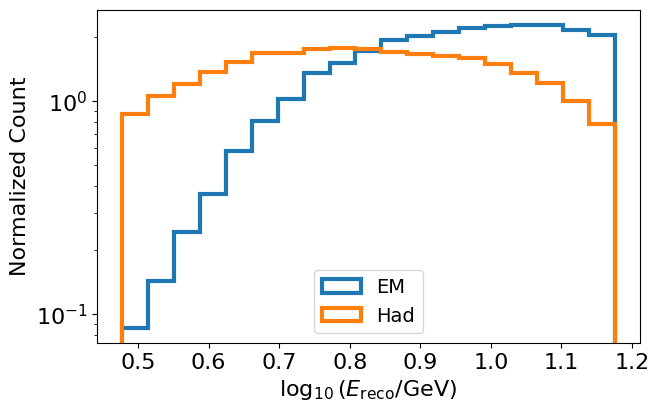

In [3]:
bins = np.linspace(np.log10(3), np.log10(15), 20)
plt.hist(np.log10(fCC.root.RecoEnergy.col('value')[(fCC.root.PrimaryEnergy.col('value') >= 3)&(fCC.root.PrimaryEnergy.col('value') <= 15)]), bins=bins, histtype='step', lw=3, log=True, density=True, label=r'EM')
plt.hist(np.log10(fNC.root.RecoEnergy.col('value')[(fNC.root.SecondaryEnergy.col('value') >= 3)&(fNC.root.SecondaryEnergy.col('value') <= 15)]), bins=bins, histtype='step', lw=3, log=True, density=True, label='Had')
plt.legend()
plt.xlabel(r'$\log_{10}(E_{\mathrm{reco}} / \mathrm{GeV})$')
plt.ylabel(r'Normalized Count')
plt.title
plt.savefig('EMvsHadronic_recoenergy_distribution_in_true_energy.pdf', bbox_inches='tight', dpi=200)

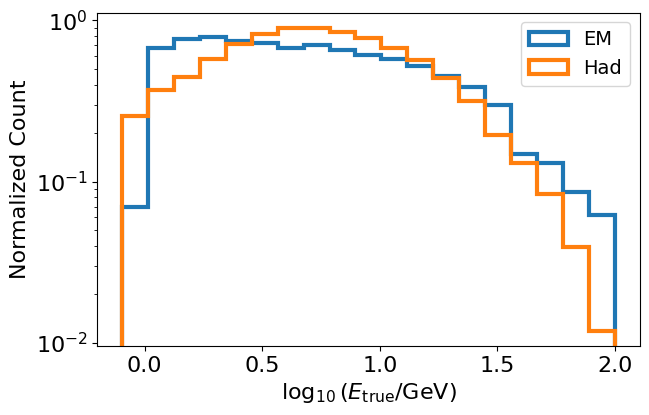

In [3]:
bins = np.linspace(np.log10(0.8), np.log10(100), 20)
plt.hist(np.log10(fCC.root.PrimaryEnergy.col('value')[(fCC.root.PrimaryEnergy.col('value') <= 100)]), bins=bins, histtype='step', lw=3, log=True, density=True, label=r'EM')
plt.hist(np.log10(fNC.root.SecondaryEnergy.col('value')[(fNC.root.SecondaryEnergy.col('value') <= 100)]), bins=bins, histtype='step', lw=3, log=True, density=True, label='Had')
plt.legend()
plt.xlabel(r'$\log_{10}(E_{\mathrm{true}} / \mathrm{GeV})$')
plt.ylabel(r'Normalized Count')
plt.savefig('EMvsHadronic_truenergy_distribution_in_true_energy.pdf', bbox_inches='tight', dpi=200)

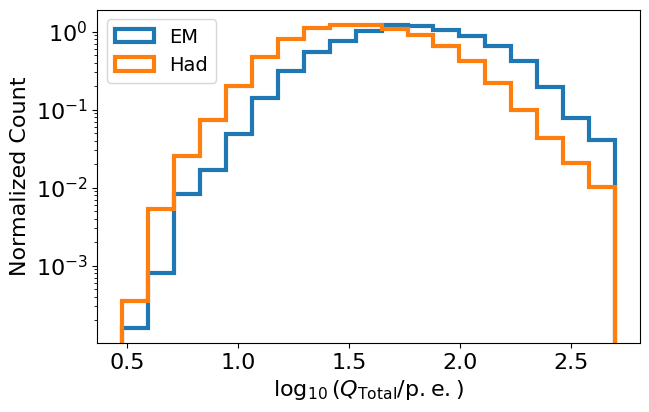

In [4]:
bins = np.linspace(np.log10(3), np.log10(500), 20)
plt.hist(np.log10(fCC.root.TotalCharge.col('value')[(fCC.root.PrimaryEnergy.col('value') >= 3)&(fCC.root.PrimaryEnergy.col('value') <= 15)]), bins=bins, histtype='step', lw=3, log=True, density=True, label=r'EM')
plt.hist(np.log10(fNC.root.TotalCharge.col('value')[(fNC.root.SecondaryEnergy.col('value') >= 3)&(fNC.root.SecondaryEnergy.col('value') <= 15)]), bins=bins, histtype='step', lw=3, log=True, density=True, label='Had')
plt.legend()
plt.xlabel(r'$\log_{10}(Q_{\mathrm{{Total}}} / \mathrm{p.e.})$')

plt.ylabel(r'Normalized Count')
plt.savefig('EMvsHadronic_totalcharge_distribution_in_true_energy.pdf', bbox_inches='tight', dpi=200)

# Reco vs True

# Energy

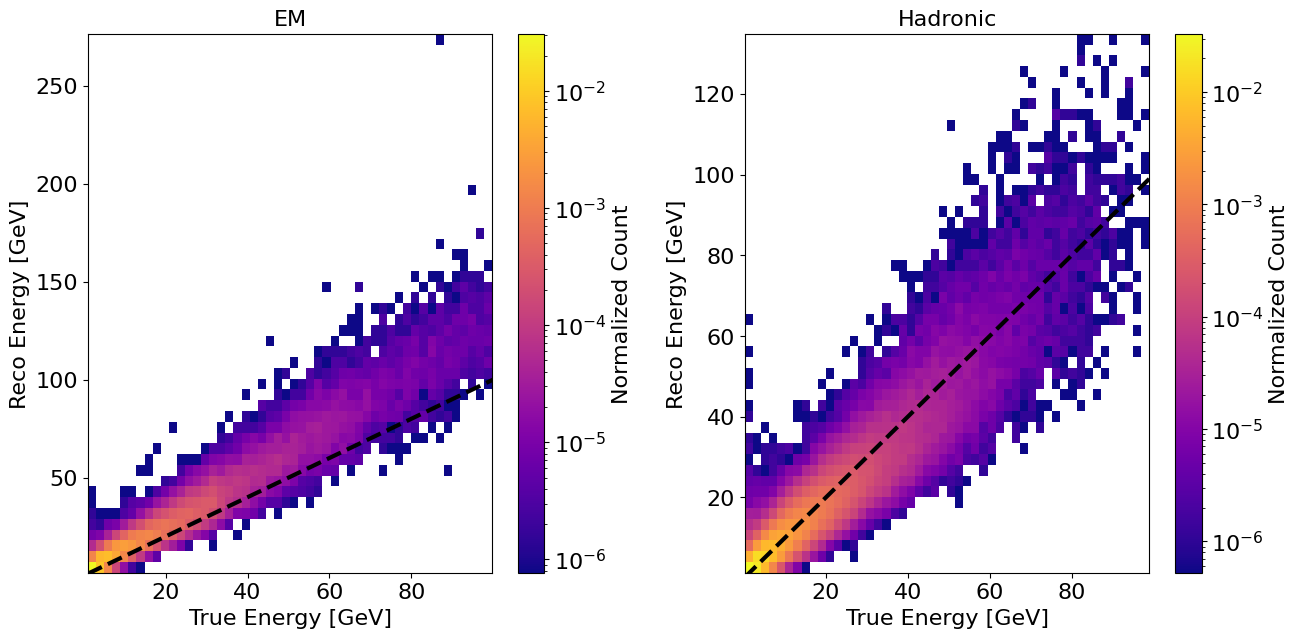

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

xCC = fCC.root.PrimaryEnergy.col('value')
yCC = fCC.root.RecoEnergy.col('value') 

a0=axs[0].hist2d(xCC, yCC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xCC.min(), yCC.min())
max_val = max(xCC.max(), yCC.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[0].set_xlabel('True Energy [GeV]')
axs[0].set_ylabel('Reco Energy [GeV]')
axs[0].set_title('EM')
cbar = fig.colorbar(a0[3], ax=axs[0], )
cbar.set_label('Normalized Count')

xNC = fNC.root.SecondaryEnergy.col('value')
yNC = fNC.root.RecoEnergy.col('value')

a1=axs[1].hist2d(xNC, yNC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xNC.min(), yNC.min())
max_val = max(xNC.max(), yNC.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[1].set_xlabel('True Energy [GeV]')
axs[1].set_ylabel('Reco Energy [GeV]')
axs[1].set_title('Hadronic')
cbar=fig.colorbar(a1[3], ax=axs[1])
cbar.set_label('Normalized Count')

plt.subplots_adjust(wspace=0.3)

plt.savefig('RecovsTrue_energy_distribution.pdf', bbox_inches='tight', dpi=200)

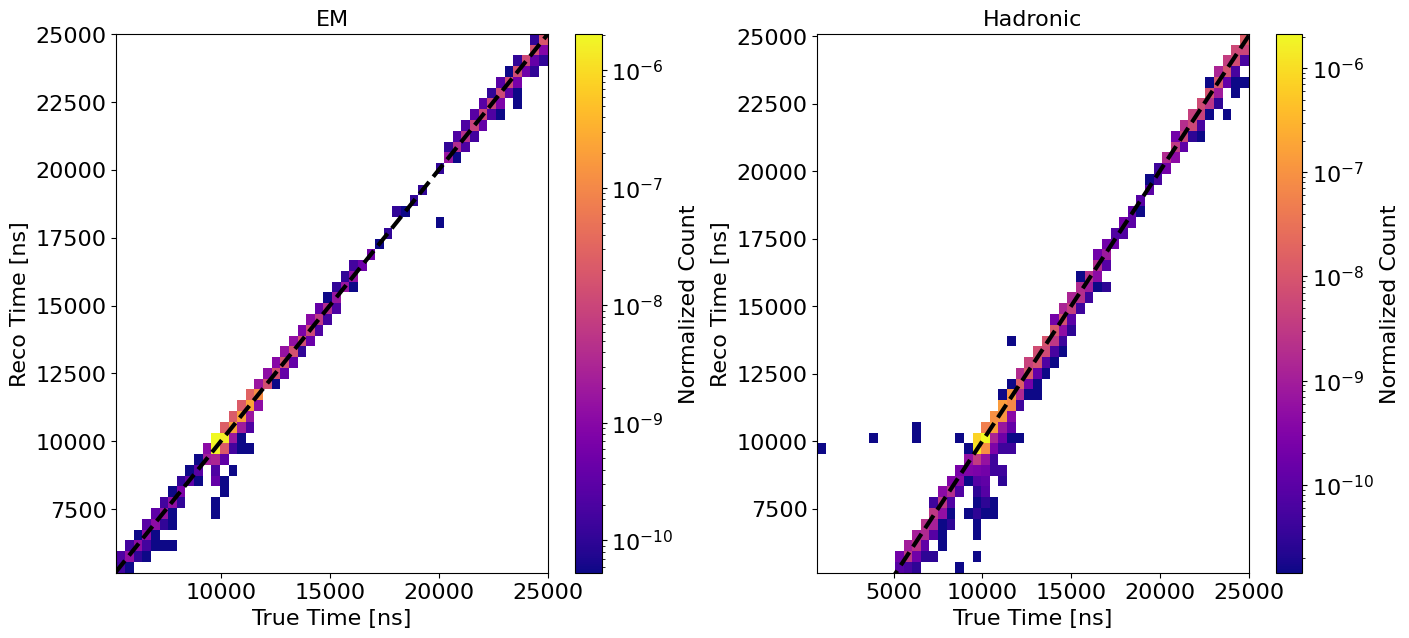

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7))

xCC = fCC.root.TrueTime.col('value')
yCC = fCC.root.RecoVertexTime.col('value') 

a0=axs[0].hist2d(xCC, yCC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xCC.min(), yCC.min())
max_val = max(xCC.max(), yCC.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[0].set_xlabel('True Time [ns]')
axs[0].set_ylabel('Reco Time [ns]')
axs[0].set_title('EM')
cbar = fig.colorbar(a0[3], ax=axs[0])
cbar.set_label('Normalized Count')

xNC = fNC.root.TrueTime.col('value')
yNC = fNC.root.RecoVertexTime.col('value')

a1=axs[1].hist2d(xNC, yNC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xNC.min(), yNC.min())
max_val = max(xNC.max(), yNC.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[1].set_xlabel('True Time [ns]')
axs[1].set_ylabel('Reco Time [ns]')
axs[1].set_title('Hadronic')
cbar = fig.colorbar(a1[3], ax=axs[1])
cbar.set_label('Normalized Count')

plt.subplots_adjust(wspace=0.3)

plt.savefig('RecovsTrue_time_distribution.pdf', bbox_inches='tight', dpi=200)

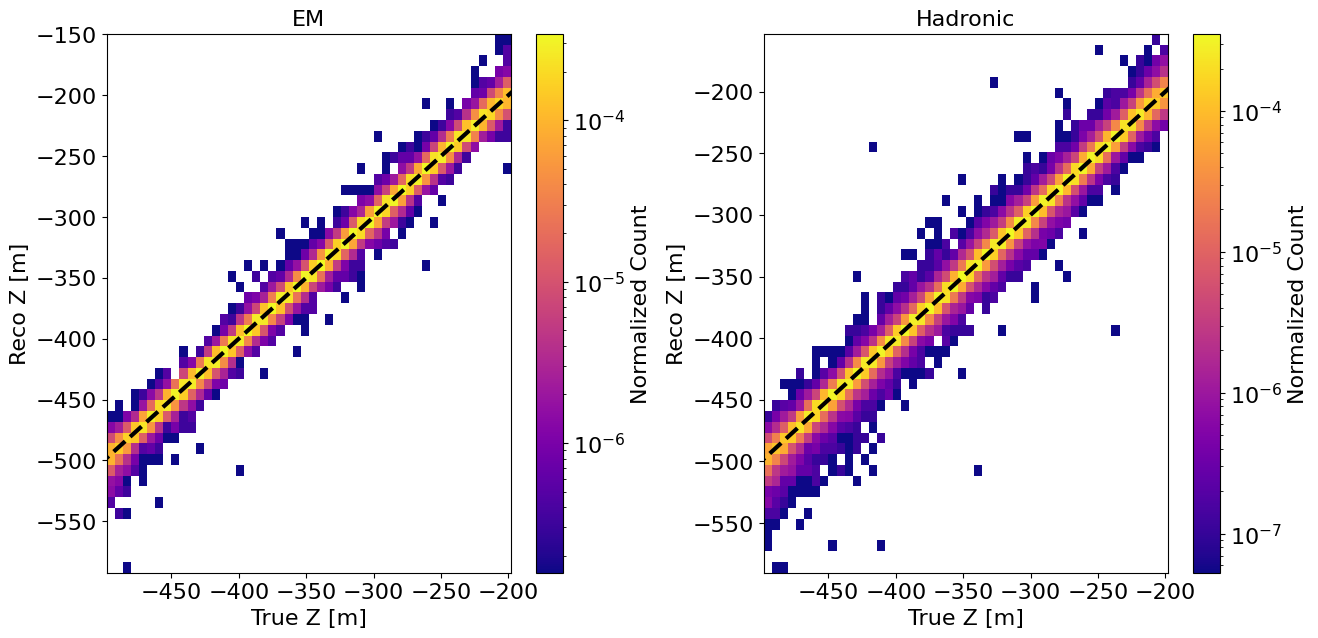

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

xCC = fCC.root.TrueZ.col('value')
yCC = fCC.root.RecoZ.col('value') 

a0=axs[0].hist2d(xCC, yCC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xCC.min(), yCC.min())
max_val = max(xCC.max(), yCC.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[0].set_xlabel('True Z [m]')
axs[0].set_ylabel('Reco Z [m]')
axs[0].set_title('EM')
cbar=fig.colorbar(a0[3], ax=axs[0])
cbar.set_label('Normalized Count')

xNC = fNC.root.TrueZ.col('value')
yNC = fNC.root.RecoZ.col('value')

a1=axs[1].hist2d(xNC, yNC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xNC.min(), yNC.min())
max_val = max(xNC.max(), yNC.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[1].set_xlabel('True Z [m]')
axs[1].set_ylabel('Reco Z [m]')
axs[1].set_title('Hadronic')
cbar=fig.colorbar(a1[3], ax=axs[1])
cbar.set_label('Normalized Count')

plt.subplots_adjust(wspace=0.3)

plt.savefig('RecovsTrue_Z_distribution.pdf', bbox_inches='tight', dpi=200)

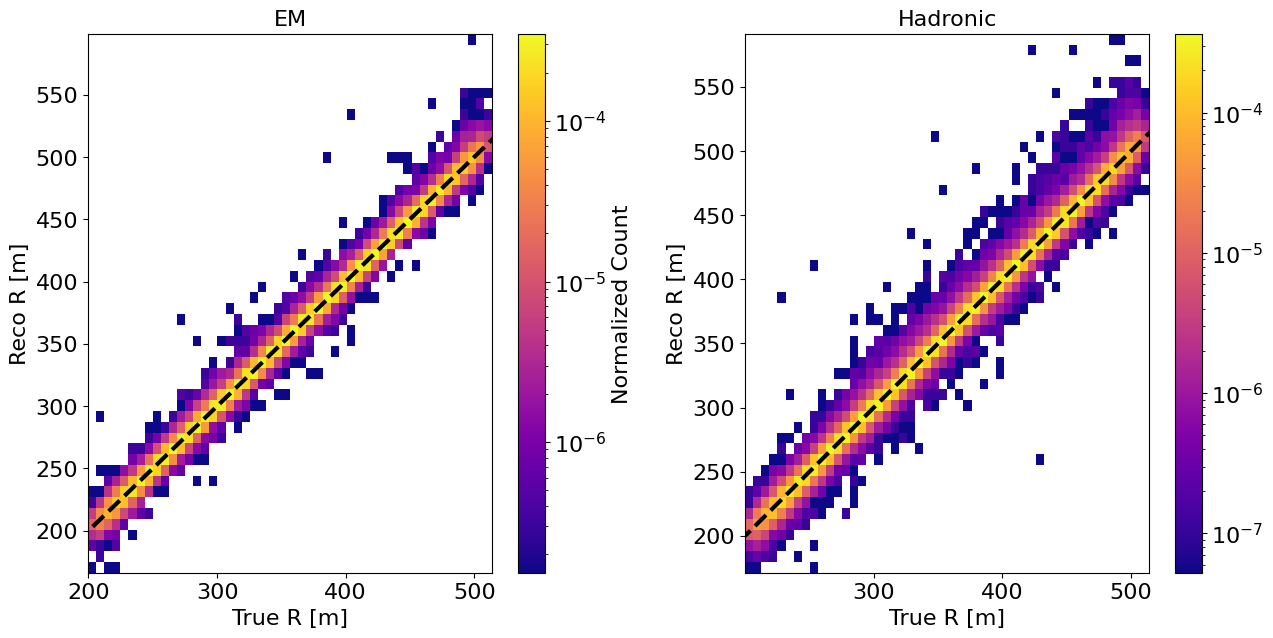

In [7]:
true_RCC = np.sqrt(fCC.root.TrueX.col('value')**2+ fCC.root.TrueY.col('value')**2+ fCC.root.TrueZ.col('value')**2)
reco_RCC = np.sqrt(fCC.root.RecoX.col('value')**2+ fCC.root.RecoY.col('value')**2+ fCC.root.RecoZ.col('value')**2)

true_RNC = np.sqrt(fNC.root.TrueX.col('value')**2+fNC.root.TrueY.col('value')**2+fNC.root.TrueZ.col('value')**2)
reco_RNC = np.sqrt(fNC.root.RecoX.col('value')**2+fNC.root.RecoY.col('value')**2+fNC.root.RecoZ.col('value')**2)

fig, axs = plt.subplots(1, 2, figsize=(15, 7))

xCC = true_RCC
yCC = reco_RCC 

a0=axs[0].hist2d(xCC, yCC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xCC.min(), yCC.min())
max_val = max(xCC.max(), yCC.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[0].set_xlabel('True R [m]')
axs[0].set_ylabel('Reco R [m]')
axs[0].set_title('EM')
cbar=fig.colorbar(a0[3], ax=axs[0])
cbar.set_label('Normalized Count')

xNC = true_RNC
yNC = reco_RNC

a1=axs[1].hist2d(xNC, yNC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xNC.min(), yNC.min())
max_val = max(xNC.max(), yNC.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[1].set_xlabel('True R [m]')
axs[1].set_ylabel('Reco R [m]')
axs[1].set_title('Hadronic')
fig.colorbar(a1[3], ax=axs[1])
cbar=cbar.set_label('Normalized Count')

plt.subplots_adjust(wspace=0.3)

plt.savefig('RecovsTrue_R_distribution.pdf', bbox_inches='tight', dpi=200)

In [8]:
def calculate_zenith_azimuth(x, y, z):

    r = np.sqrt((x)**2 + (y)**2 + (z)**2)
    theta = np.arccos(z/r)
    phi = np.arctan2(y, x)

    phi[phi < 0] = phi[phi < 0] + 2*np.pi

    return theta, phi
    
true_zenithCC, true_azimuthCC = fCC.root.Zenith.col('value'), fCC.root.Azimuth.col('value')
reco_zenithCC, reco_azimuthCC = calculate_zenith_azimuth(fCC.root.RecoDirX.col('value'), fCC.root.RecoDirY.col('value'), fCC.root.RecoDirZ.col('value'))

true_zenithNC, true_azimuthNC = fNC.root.Zenith.col('value'), fNC.root.Azimuth.col('value')
reco_zenithNC, reco_azimuthNC = calculate_zenith_azimuth(fNC.root.RecoDirX.col('value'), fNC.root.RecoDirY.col('value'), fNC.root.RecoDirZ.col('value'))

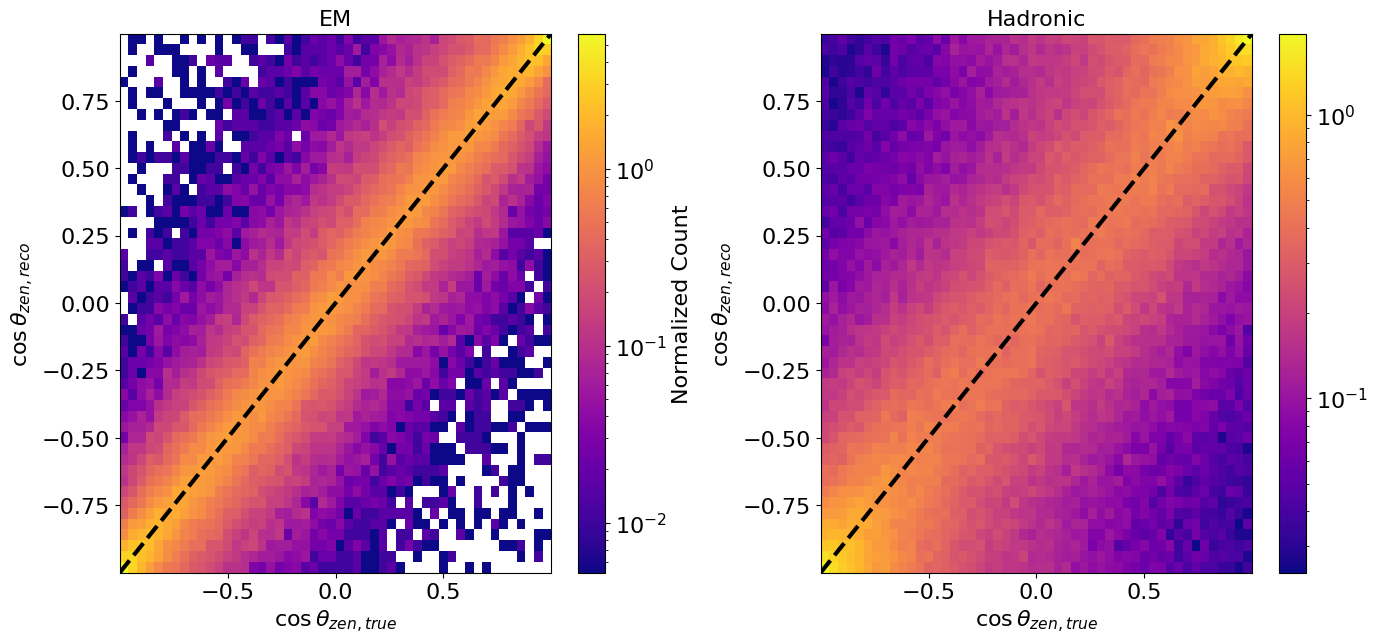

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7))

xCC = np.cos(true_zenithCC)
yCC = np.cos(reco_zenithCC) 

a0=axs[0].hist2d(xCC, yCC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xCC.min(), yCC.min())
max_val = max(xCC.max(), yCC.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[0].set_xlabel(r'$\cos{\theta}_{zen,true}$')
axs[0].set_ylabel(r'$\cos{\theta}_{zen,reco}$')
axs[0].set_title('EM')
cbar=fig.colorbar(a0[3], ax=axs[0])
cbar.set_label('Normalized Count')

xNC = np.cos(true_zenithNC)
yNC = np.cos(reco_zenithNC)

a1=axs[1].hist2d(xNC, yNC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xNC.min(), yNC.min())
max_val = max(xNC.max(), yNC.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[1].set_xlabel(r'$\cos{\theta}_{zen,true}$')
axs[1].set_ylabel(r'$\cos{\theta}_{zen,reco}$')
axs[1].set_title('Hadronic')
fig.colorbar(a1[3], ax=axs[1])
cbar=cbar.set_label('Normalized Count')

plt.subplots_adjust(wspace=0.3)

plt.savefig('RecovsTrue_cos_zenith_distribution.pdf', bbox_inches='tight', dpi=200)

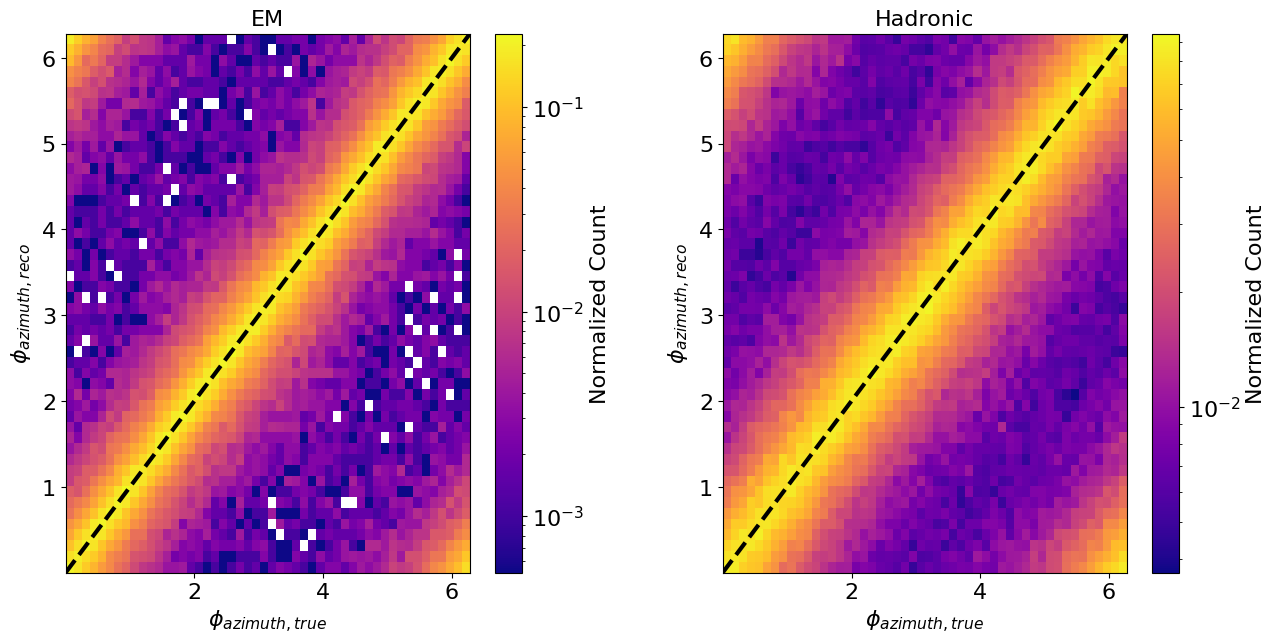

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

xCC = true_azimuthCC 
yCC = reco_azimuthCC

a0=axs[0].hist2d(xCC, yCC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xCC.min(), yCC.min())
max_val = max(xCC.max(), yCC.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[0].set_xlabel(r'$\phi_{azimuth, true}$')
axs[0].set_ylabel(r'$\phi_{azimuth, reco}$')
axs[0].set_title('EM')
cbar=fig.colorbar(a0[3], ax=axs[0])
cbar.set_label('Normalized Count')

xNC = true_azimuthNC
yNC = reco_azimuthNC

a1=axs[1].hist2d(xNC, yNC, bins=50, norm=LogNorm(), density=True, cmap=plt.cm.plasma)
min_val = min(xNC.min(), yNC.min())
max_val = max(xNC.max(), yNC.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3)
axs[1].set_xlabel(r'$\phi_{azimuth, true}$')
axs[1].set_ylabel(r'$\phi_{azimuth, reco}$')
axs[1].set_title('Hadronic')
cbar=fig.colorbar(a1[3], ax=axs[1])
cbar.set_label('Normalized Count')

plt.subplots_adjust(wspace=0.3)

plt.savefig('RecovsTrue_azimuth_distribution.pdf', bbox_inches='tight', dpi=200)

# Variable Definitions

In [3]:
#### CC Variables #####
om_reco_energyCC = fCC.root.OMMapReco.col('om_renergy')
time_resCC = fCC.root.OMMapReco.col('time_residual')
angleCC = fCC.root.OMMapReco.col('angle')
distCC = fCC.root.OMMapReco.col('distance')

reco_energyCC = fCC.root.RecoEnergy.col('value')
beta1CC = fCC.root.Beta1Reco.col('value')
cogCC = np.sqrt((fCC.root.CogX.col('value')-fCC.root.RecoX.col('value'))**2+
                 (fCC.root.CogY.col('value')-fCC.root.RecoY.col('value'))**2+
                 (fCC.root.CogZ.col('value')-fCC.root.RecoZ.col('value'))**2)

om_boolCC = (om_reco_energyCC>=3) & (om_reco_energyCC<=15)
boolCC = (reco_energyCC>=3) & (reco_energyCC<=15)

##### NC Variables #####

om_reco_energyNC = fNC.root.OMMapReco.col('om_renergy')
time_resNC = fNC.root.OMMapReco.col('time_residual')
angleNC = fNC.root.OMMapReco.col('angle')
distNC = fNC.root.OMMapReco.col('distance')

reco_energyNC = fNC.root.SecondaryEnergy.col('value')
beta1NC = fNC.root.Beta1Reco.col('value')
cogNC = np.sqrt((fNC.root.CogX.col('value')-fNC.root.RecoX.col('value'))**2+
                 (fNC.root.CogY.col('value')-fNC.root.RecoY.col('value'))**2+
                 (fNC.root.CogZ.col('value')-fNC.root.RecoZ.col('value'))**2)

om_boolNC = (om_reco_energyNC>=3) & (om_reco_energyNC<=15)
boolNC = (reco_energyNC>=3) & (reco_energyNC<=15)

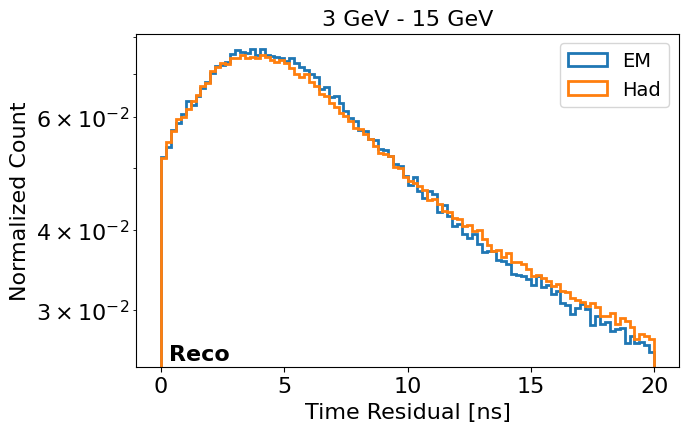

In [6]:
plt.hist(time_resCC[om_boolCC][(time_resCC[om_boolCC] >= 1e-12) & (time_resCC[om_boolCC] <= 20)], bins=100, histtype='step', lw=2, log=True, density=True, label='EM')
plt.hist(time_resNC[om_boolNC][(time_resNC[om_boolNC] >= 1e-12) & (time_resNC[om_boolNC] <= 20)], bins=100, histtype='step', lw=2, log=True, density=True, label='Had')
plt.text(0.06, 0.02, "Reco",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')
plt.legend()
plt.xlabel('Time Residual [ns]')
plt.ylabel('Normalized Count')
plt.title('3 GeV - 15 GeV')
plt.savefig('reco_time_residual_distribution.pdf', bbox_inches='tight', dpi=200)

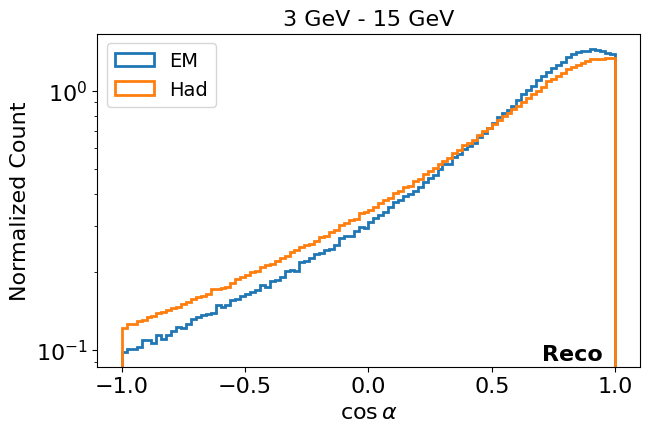

In [11]:
plt.hist(np.cos(angleCC[om_boolCC]), bins=100, histtype='step', lw=2, log=True, density=True, label='EM')
plt.hist(np.cos(angleNC[om_boolNC]), bins=100, histtype='step', lw=2, log=True, density=True, label='Had')
plt.text(0.82, 0.02, "Reco",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')
plt.legend()
plt.xlabel(r'$\cos{\alpha}$')
plt.ylabel('Normalized Count')
plt.title('3 GeV - 15 GeV')
plt.savefig('reco_angle_distribution.pdf', bbox_inches='tight', dpi=200)

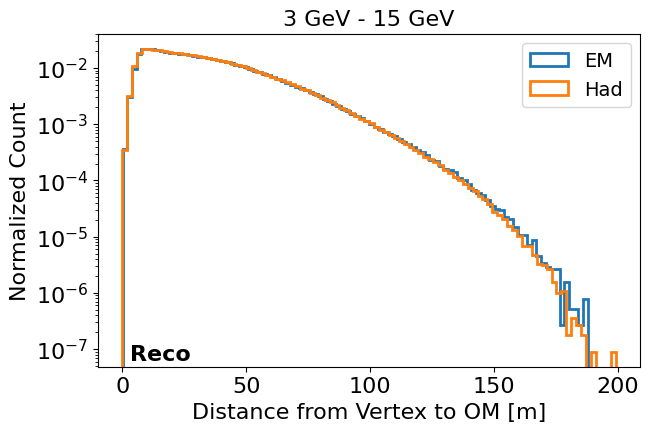

In [14]:
plt.hist(distCC[om_boolCC][(distCC[om_boolCC] >= 0) & (distCC[om_boolCC] <= 200)], bins=100, histtype='step', lw=2, log=True, density=True, label='EM')
plt.hist(distNC[om_boolNC][(distNC[om_boolNC] >= 0) & (distNC[om_boolNC] <= 200)], bins=100, histtype='step', lw=2, log=True, density=True, label='Had')
plt.text(0.06, 0.02, "Reco",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')
plt.legend()
plt.xlabel(r'Distance from Vertex to OM [m]')
plt.ylabel('Normalized Count')
plt.title('3 GeV - 15 GeV')
plt.savefig('reco_distance_distribution.pdf', bbox_inches='tight', dpi=200)

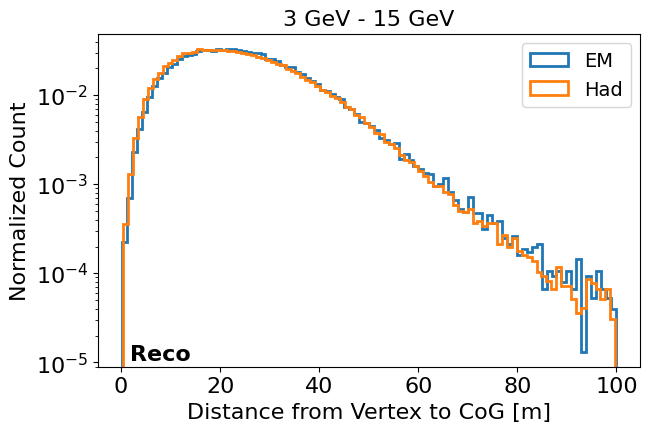

In [16]:
plt.hist(cogCC[boolCC][(cogCC[boolCC] >= 0) & (cogCC[boolCC] <= 100)], bins=100, histtype='step', lw=2, log=True, density=True, label='EM')
plt.hist(cogNC[boolNC][(cogNC[boolNC] >= 0) & (cogNC[boolNC] <= 100)], bins=100, histtype='step', lw=2, log=True, density=True, label='Had')
plt.text(0.06, 0.02, "Reco",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')
plt.legend()
plt.xlabel(r'Distance from Vertex to CoG [m]')
plt.ylabel('Normalized Count')
plt.title('3 GeV - 15 GeV')
plt.savefig('reco_cog_distribution.pdf', bbox_inches='tight', dpi=200)

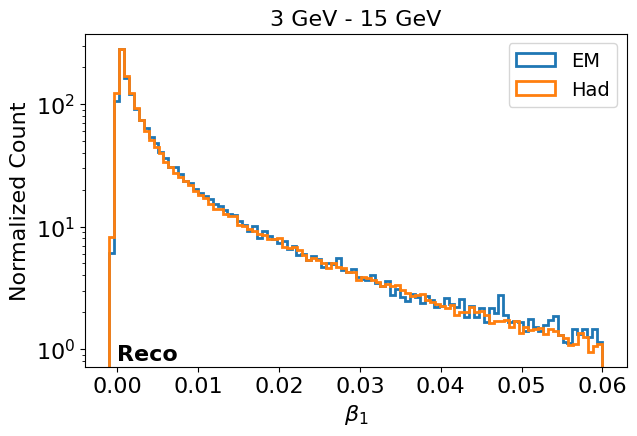

In [18]:
plt.hist(beta1CC[boolCC][(beta1CC[boolCC] >= -0.001) & (beta1CC[boolCC] <= 0.06)], bins=100, histtype='step', lw=2, log=True, density=True, label='EM')
plt.hist(beta1NC[boolNC][(beta1NC[boolNC] >= -0.001) & (beta1NC[boolNC] <= 0.06)], bins=100, histtype='step', lw=2, log=True, density=True, label='Had')
plt.text(0.06, 0.02, "Reco",
         transform=plt.gca().transAxes,
         fontsize=16,
         fontweight='bold')
plt.legend()
plt.xlabel(r'$\beta_1$')
plt.ylabel('Normalized Count')
plt.title('3 GeV - 15 GeV')
plt.savefig('reco_beta1_distribution.pdf', bbox_inches='tight', dpi=200)